<a href="https://colab.research.google.com/github/mdrizvi-106/coral-reef-classification/blob/main/Coral_Reef_Health_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Coral Reef Health Classifier

Dataset  : Bleached vs Healthy Corals (Kaggle - aneeshdighe)
Backbone : EfficientNetB0 (ImageNet pretrained) — transfer learning
Training : Two-phase (feature extraction → fine-tuning)

##KAGGLE AUTHENTICATION

In [18]:
import os

os.environ["KAGGLE_USERNAME"] = "mrsa106"
os.environ["KAGGLE_KEY"]      = "KGAT_04bf67eb534e0164be981daf92bb97ad"

os.makedirs('/root/.config/kaggle', exist_ok=True)
with open('/root/.config/kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"mrsa106","key":"KGAT_04bf67eb534e0164be981daf92bb97ad"}')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

print("✓ Kaggle auth configured")

✓ Kaggle auth configured


##INSTALL & IMPORTS

In [19]:
import subprocess
subprocess.run(["pip", "install", "-q", "kaggle"], check=True)

import shutil
import kaggle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

print("✓ All imports successful")
print(f"✓ TensorFlow version: {tf.__version__}")

✓ All imports successful
✓ TensorFlow version: 2.19.0


##DOWNLOAD DATASET FROM KAGGLE

In [20]:
KAGGLE_DATASET = "aneeshdighe/corals-classification"
DOWNLOAD_DIR   = "/content/kaggle_download"
RAW_DATA       = "/content/raw_data"

def download_dataset():
    if os.path.exists(RAW_DATA) and len(os.listdir(RAW_DATA)) > 0:
        print(f"[INFO] Dataset already downloaded, skipping.")
        return

    print("[INFO] Downloading dataset from Kaggle...")
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)

    kaggle.api.dataset_download_files(
        KAGGLE_DATASET,
        path=DOWNLOAD_DIR,
        unzip=True,
        quiet=False,
    )

    if os.path.exists(RAW_DATA):
        shutil.rmtree(RAW_DATA)
    shutil.copytree(DOWNLOAD_DIR, RAW_DATA)
    shutil.rmtree(DOWNLOAD_DIR)
    print("[INFO] Download complete.")

download_dataset()

# Show folder structure
print("\n[INFO] Dataset structure:")
for root, dirs, files in os.walk(RAW_DATA):
    level = root.replace(RAW_DATA, '').count(os.sep)
    if level > 3:
        continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if files:
        print(f"{'  ' * (level+1)}{len(files)} images")


[INFO] Downloading dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/aneeshdighe/corals-classification


100%|██████████| 134M/134M [00:01<00:00, 134MB/s]



[INFO] Download complete.

[INFO] Dataset structure:
raw_data/
  Bleached Corals and Healthy Corals Classification/
    1 images
    Testing/
      healthy_corals/
        438 images
      bleached_corals/
        485 images
    Training/
      healthy_corals/
        3504 images
      bleached_corals/
        3880 images
    Validation/
      healthy_corals/
        500 images
      bleached_corals/
        485 images


##SET CORRECT DATA PATHS
The dataset is pre-split into Training / Validation / Testing folders

In [21]:
BASE        = "/content/raw_data/Bleached Corals and Healthy Corals Classification"
TRAIN_DATA  = os.path.join(BASE, "Training")
VAL_DATA    = os.path.join(BASE, "Validation")
TEST_DATA   = os.path.join(BASE, "Testing")

IMG   = 224
BATCH = 16

print(f"Train path : {TRAIN_DATA}")
print(f"Val path   : {VAL_DATA}")
print(f"Test path  : {TEST_DATA}")
print(f"\nTrain classes : {os.listdir(TRAIN_DATA)}")
print(f"Val classes   : {os.listdir(VAL_DATA)}")

Train path : /content/raw_data/Bleached Corals and Healthy Corals Classification/Training
Val path   : /content/raw_data/Bleached Corals and Healthy Corals Classification/Validation
Test path  : /content/raw_data/Bleached Corals and Healthy Corals Classification/Testing

Train classes : ['healthy_corals', 'bleached_corals']
Val classes   : ['healthy_corals', 'bleached_corals']


##DATA GENERATORS

In [22]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.75, 1.25],
    shear_range=0.1,
)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train = train_gen.flow_from_directory(
    TRAIN_DATA, target_size=(IMG, IMG), batch_size=BATCH,
    class_mode="categorical", shuffle=True
)
val = val_gen.flow_from_directory(
    VAL_DATA, target_size=(IMG, IMG), batch_size=BATCH,
    class_mode="categorical", shuffle=False
)

NUM_CLASSES = len(train.class_indices)
CLASS_NAMES = {v: k for k, v in train.class_indices.items()}

print(f"\n✓ Classes : {train.class_indices}")
print(f"✓ Train   : {train.samples} images")
print(f"✓ Val     : {val.samples} images")

Found 7384 images belonging to 2 classes.
Found 985 images belonging to 2 classes.

✓ Classes : {'bleached_corals': 0, 'healthy_corals': 1}
✓ Train   : 7384 images
✓ Val     : 985 images


##CLASS IMBALANCE WEIGHTS

In [23]:
class_weights = {
    i: len(train.classes) / (NUM_CLASSES * sum(train.classes == i))
    for i in range(NUM_CLASSES)
}
print("Class weights:", {CLASS_NAMES[k]: f"{v:.2f}" for k, v in class_weights.items()})

Class weights: {'bleached_corals': '0.95', 'healthy_corals': '1.05'}


##BUILD MODEL (EfficientNetB0 + custom head)

In [24]:
def build_model(num_classes, trainable_backbone=False):
    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG, IMG, 3),
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    inputs  = tf.keras.Input(shape=(IMG, IMG, 3))
    x       = backbone(inputs, training=False)
    x       = tf.keras.layers.GlobalAveragePooling2D()(x)
    x       = tf.keras.layers.BatchNormalization()(x)
    x       = tf.keras.layers.Dense(256, activation="relu")(x)
    x       = tf.keras.layers.Dropout(0.5)(x)
    x       = tf.keras.layers.Dense(128, activation="relu")(x)
    x       = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs), backbone

model, backbone = build_model(NUM_CLASSES, trainable_backbone=False)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,415,781 (16.84 MB)

 Trainable params: 363,650 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

##PHASE 1: FEATURE EXTRACTION (backbone fully frozen)
Only the custom head trains here.

Expected: accuracy climbs gradually from ~60-70% upward.

In [25]:
print("\n========== PHASE 1: Feature Extraction ==========\n")

EPOCHS_FE = 10

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history1 = model.fit(
    train,
    validation_data=val,
    epochs=EPOCHS_FE,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=4,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint("/content/best_phase1.keras",
                        monitor="val_accuracy", save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, min_lr=1e-6, verbose=1),
    ],
)


========== PHASE 1: Feature Extraction ==========

Epoch 1/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.6626 - loss: 0.7938
Epoch 1: val_accuracy improved from None to 0.75736, saving model to /content/best_phase1.keras

Epoch 1: finished saving model to /content/best_phase1.keras
462/462 ━━━━━━━━━━━━━━━━━━━━ 160s 301ms/step - accuracy: 0.6876 - loss: 0.6767 - val_accuracy: 0.7574 - val_loss: 0.5025 - learning_rate: 0.0010
Epoch 2/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7488 - loss: 0.5184
Epoch 2: val_accuracy improved from 0.75736 to 0.81320, saving model to /content/best_phase1.keras

Epoch 2: finished saving model to /content/best_phase1.keras
462/462 ━━━━━━━━━━━━━━━━━━━━ 104s 224ms/step - accuracy: 0.7541 - loss: 0.5070 - val_accuracy: 0.8132 - val_loss: 0.4330 - learning_rate: 0.0010
Epoch 3/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7643 - loss: 0.4869
Epoch 3: val_accuracy improved from 0.81320 to 0.81421, saving model to /co

##PHASE 2: FINE-TUNING (top 30 backbone layers unfrozen)
Very low LR to gently adapt pretrained weights to coral imagery.

In [26]:
print("\n========== PHASE 2: Fine-Tuning ==========\n")

EPOCHS_FT = 20

backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),   # very low LR
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history2 = model.fit(
    train,
    validation_data=val,
    epochs=EPOCHS_FT,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=6,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint("/content/best_model_final.keras",
                        monitor="val_accuracy", save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                          patience=3, min_lr=1e-7, verbose=1),
    ],
)


========== PHASE 2: Fine-Tuning ==========

Epoch 1/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.7664 - loss: 0.4774
Epoch 1: val_accuracy improved from None to 0.83858, saving model to /content/best_model_final.keras

Epoch 1: finished saving model to /content/best_model_final.keras
462/462 ━━━━━━━━━━━━━━━━━━━━ 158s 282ms/step - accuracy: 0.7738 - loss: 0.4707 - val_accuracy: 0.8386 - val_loss: 0.3766 - learning_rate: 1.0000e-05
Epoch 2/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7846 - loss: 0.4605
Epoch 2: val_accuracy improved from 0.83858 to 0.84772, saving model to /content/best_model_final.keras

Epoch 2: finished saving model to /content/best_model_final.keras
462/462 ━━━━━━━━━━━━━━━━━━━━ 104s 225ms/step - accuracy: 0.7886 - loss: 0.4508 - val_accuracy: 0.8477 - val_loss: 0.3605 - learning_rate: 1.0000e-05
Epoch 3/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.7950 - loss: 0.4273
Epoch 3: val_accuracy improved from 0.84772 to 0.85178

##TRAINING HISTORY PLOT

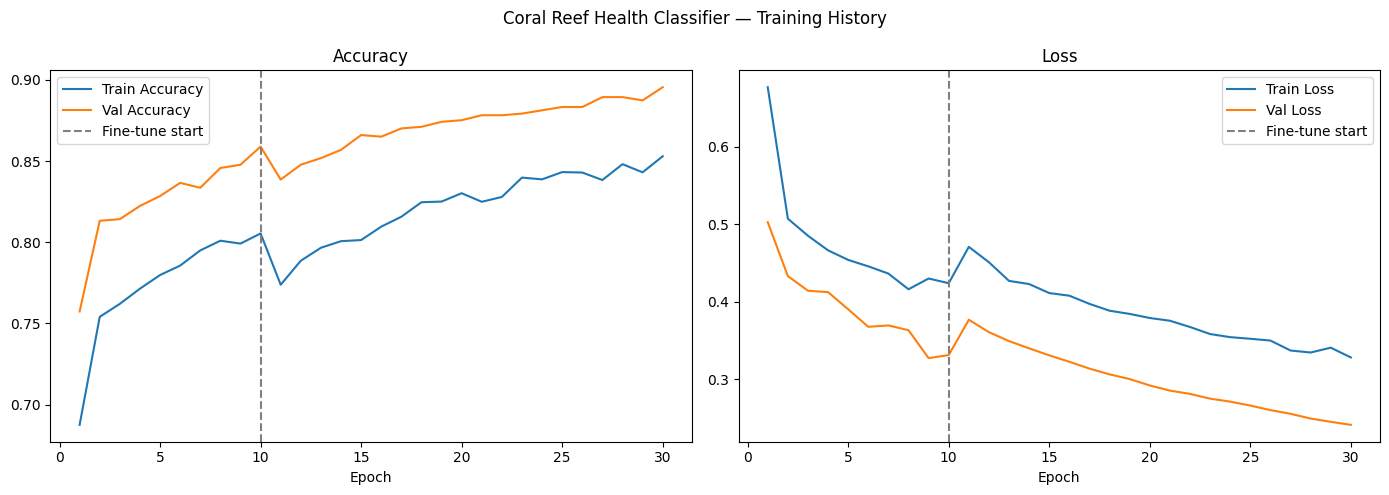

✓ Plot saved → /content/training_history.png


In [27]:
def plot_history(h1, h2):
    acc   = h1.history["accuracy"]     + h2.history["accuracy"]
    val_a = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss  = h1.history["loss"]         + h2.history["loss"]
    val_l = h1.history["val_loss"]     + h2.history["val_loss"]
    ep    = range(1, len(acc) + 1)
    split = len(h1.history["accuracy"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, train_m, val_m, title in [
        (ax1, acc,  val_a, "Accuracy"),
        (ax2, loss, val_l, "Loss"),
    ]:
        ax.plot(ep, train_m, label=f"Train {title}")
        ax.plot(ep, val_m,   label=f"Val {title}")
        ax.axvline(split, color="grey", linestyle="--", label="Fine-tune start")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()

    plt.suptitle("Coral Reef Health Classifier — Training History")
    plt.tight_layout()
    plt.savefig("/content/training_history.png", dpi=150)
    plt.show()
    print("✓ Plot saved → /content/training_history.png")

plot_history(history1, history2)

##EVALUATION ON TEST SET

In [28]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test = test_gen.flow_from_directory(
    TEST_DATA, target_size=(IMG, IMG), batch_size=BATCH,
    class_mode="categorical", shuffle=False
)

loss, accuracy = model.evaluate(test)
print(f"\n✓ Test Accuracy : {accuracy:.1%}")
print(f"✓ Test Loss     : {loss:.4f}")

Found 923 images belonging to 2 classes.
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.9047 - loss: 0.2266

✓ Test Accuracy : 90.5%
✓ Test Loss     : 0.2266


##PREDICTION ON A SINGLE IMAGE
Upload any coral reef image when prompted

In [30]:
from google.colab import files

print("Upload a coral reef image to test:")
uploaded = files.upload()
TEST_IMG = list(uploaded.keys())[0]

def predict(image_path):
    img  = load_img(image_path, target_size=(IMG, IMG))
    x    = preprocess_input(np.expand_dims(img_to_array(img), axis=0))
    pred = model.predict(x)[0]

    print(f"\n--- Prediction: {image_path} ---")
    for i, prob in enumerate(pred):
        bar = "█" * int(prob * 40)
        print(f"  {CLASS_NAMES[i]:<20} {prob:.1%}  {bar}")
    print(f"\n  ➜  Predicted : {CLASS_NAMES[int(np.argmax(pred))]}"
          f"  (confidence: {float(np.max(pred)):.1%})")

predict(TEST_IMG)

Upload a coral reef image to test:


Saving istockphoto-1149827862-612x612.jpg to istockphoto-1149827862-612x612.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

--- Prediction: istockphoto-1149827862-612x612.jpg ---
  bleached_corals      69.4%  ███████████████████████████
  healthy_corals       30.6%  ████████████

  ➜  Predicted : bleached_corals  (confidence: 69.4%)
